# **Librairies**



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Descriptive Analysis**

## **Import du dataframe**

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

## **Visualiation classique du df**

In [3]:
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

We noticed some missing values ​​for the variables Teacher_Quality, Parent_Education_Level and Distance_From_Home.

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## **Check Quality**

Checking data quality ensures that:
* All fields are completed
* Values ​​are realistic
* There are no duplicates
* Categories are balanced


In [6]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
print(f"Valeurs manquantes : \n{missing_data}")
print(f"\nPourcentage par rapport aux données : \n{missing_percent}")

Valeurs manquantes : 
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Pourcentage par rapport aux données : 
Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0

**IL FAUT DONC TRAITER LES DONNEES POUR SUPPRIMER LES VALEURS MANQUANTES.**
Pour le traiter les données manquantes j'ai demandé au prof, il faut d'abord voir les variables sont très corrélées aux autres ou si pas trop.
Ensuite comme ça représente que 1% des données, ça serait bête de supprimer toute la colonne. Dcp ce qu'il propose c'est par exemple de regarder les valeurs qui tombent le plus et de remplacer les valeurs inconnus par cette valeur la ou de créer une nouvelle option de réponse pour la colonne "Inconnu" et de traiter avec cette donnée.



**On pourra faire par exemple les deux cas, et changer et tester notre modèek pour les deux cas et garder celui qui a le meilleur rendement, même si la comme ça concerne qu'un petit nombre de données ce n'est pas ça qui va avoir un changement significatif.**


In [7]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


## **Visualisation de la distributions des variables**

Distribution des variables numériques


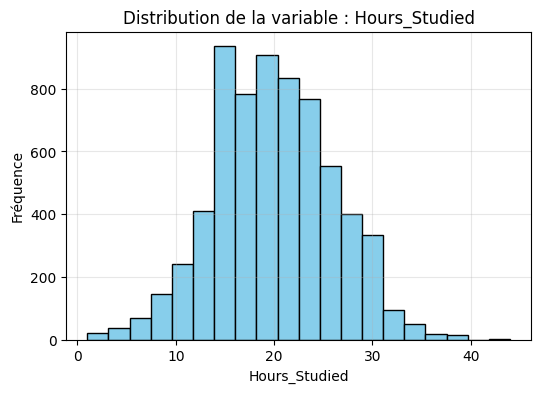

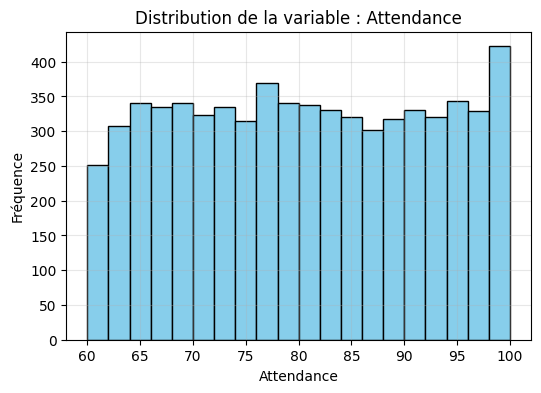

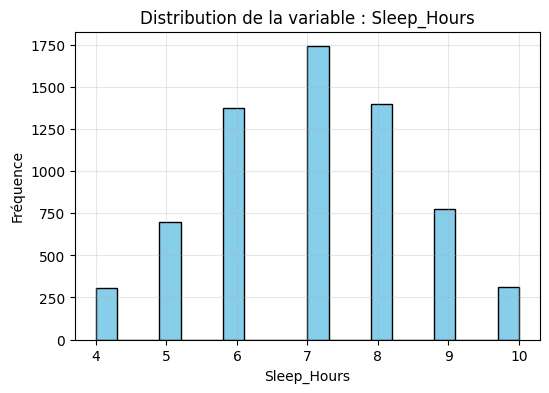

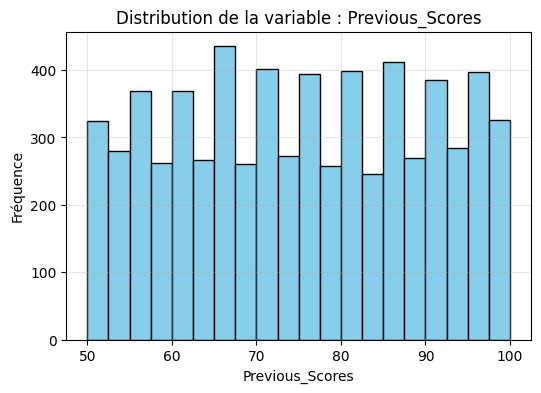

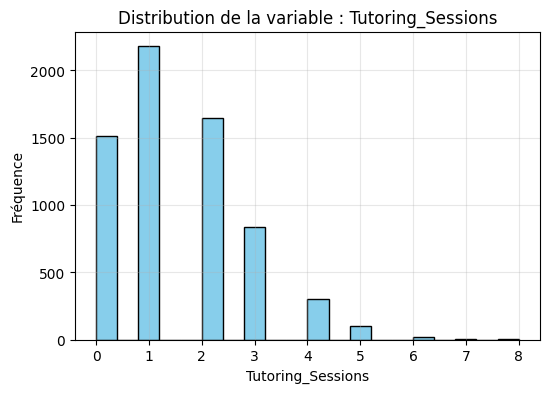

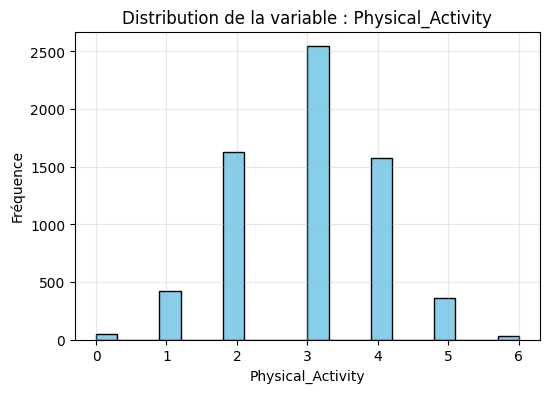

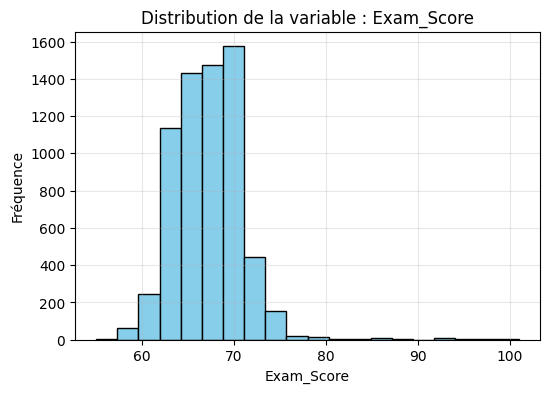

In [10]:
print("Distribution des variables numériques")
colonnes_numeriques = df.select_dtypes(include=['int64', 'float64']).columns

for col in colonnes_numeriques:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Distribution de la variable : {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.grid(True, alpha=0.3)
    plt.show()

Distribution des variables catégorielles


/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


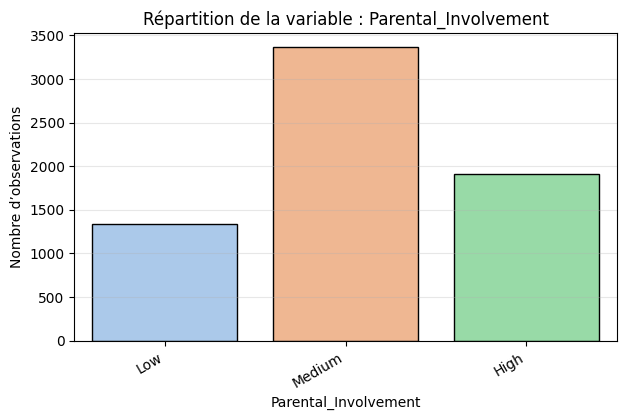

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


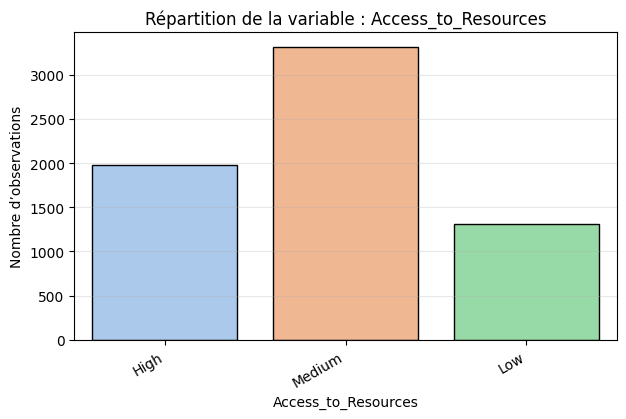

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


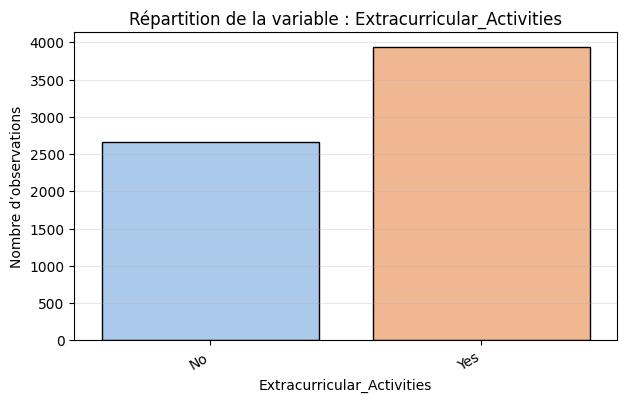

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


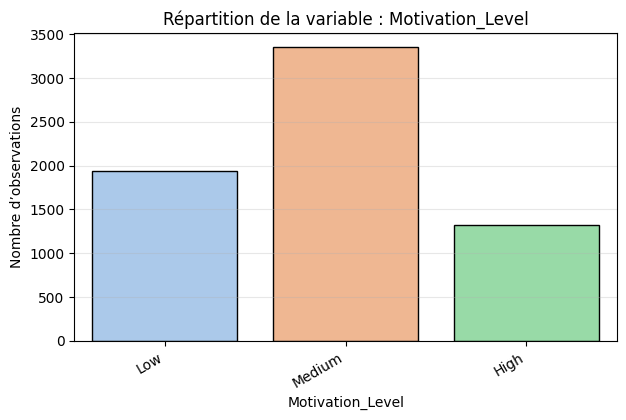

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


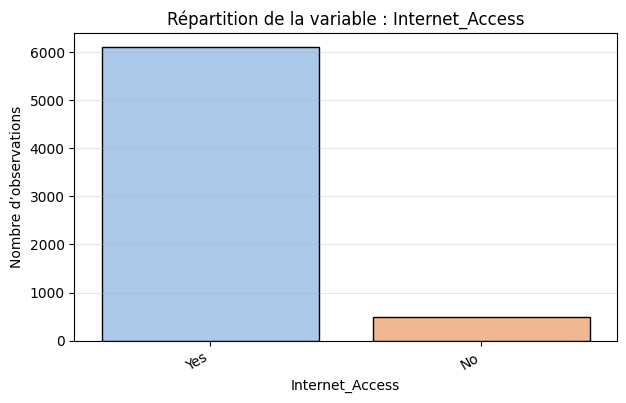

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


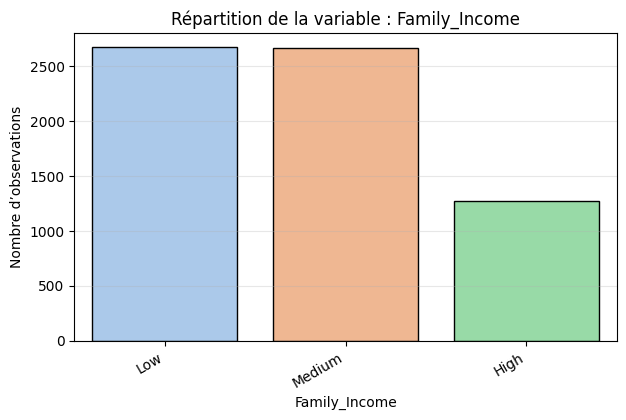

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


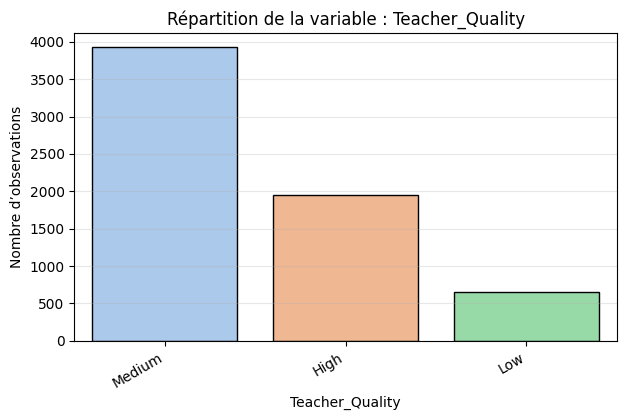

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


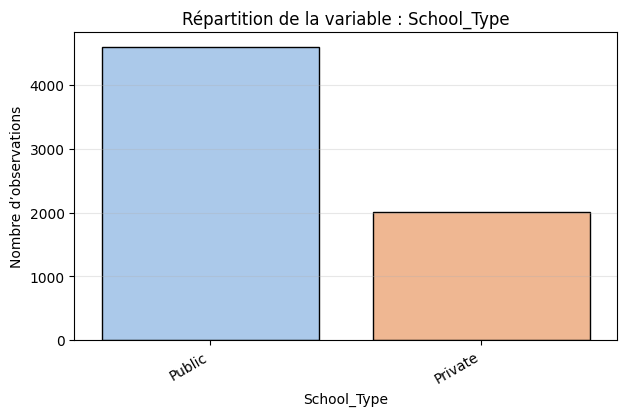

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


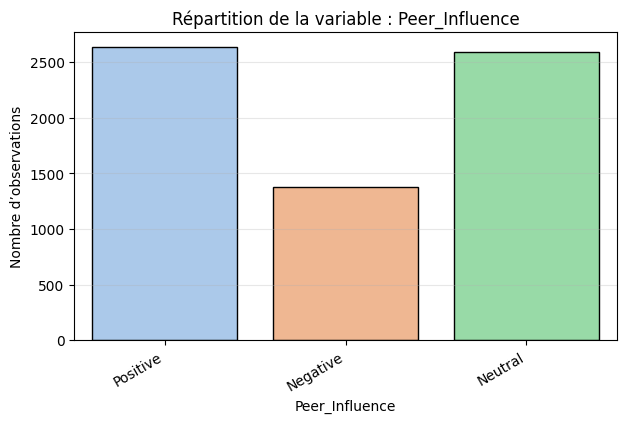

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


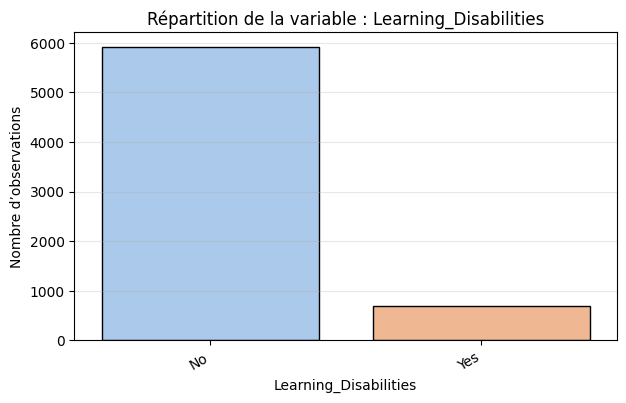

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


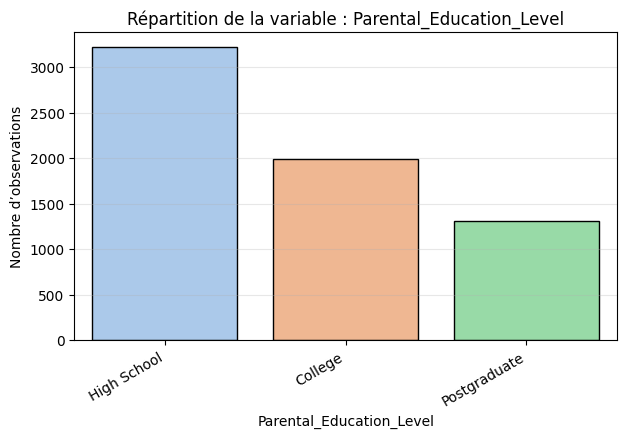

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


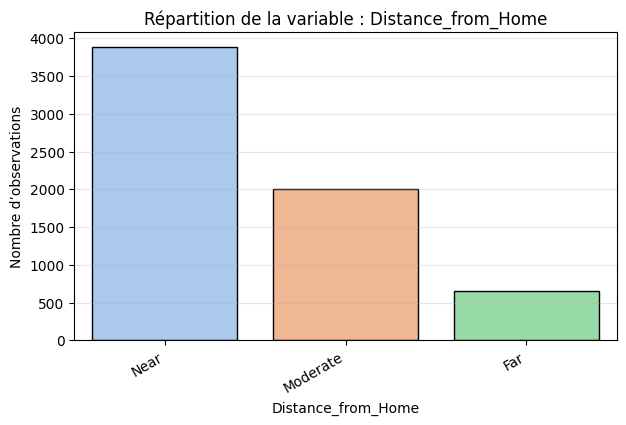

/tmp/ipython-input-1843790459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


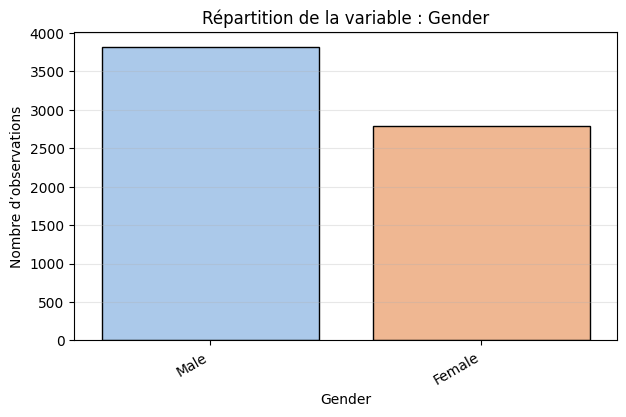

In [11]:
print("Distribution des variables catégorielles")

colonnes_categorielle = df.select_dtypes(include=['object']).columns
for col in colonnes_categorielle:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')
    plt.title(f"Répartition de la variable : {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre d’observations")
    plt.xticks(rotation=30, ha='right')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

## **Traitement des variables catégorielles**

To process the categorical variables, we will encode them. We chose not to use binary encoding because we often had more than two answer options for the variables. We didn't choose the "numeric" method because that would imply that 1 would be more important than 2, for example, but in our categorical variables, it doesn't make sense to say that Low is stronger than Medium. Therefore, we decided to use `get_dummies` to create new columns for each option, populating them with binary data to allow us to use and interpret the correlations between the variables.


In [14]:
colonnes_categorielles = df.select_dtypes(include=['object']).columns.tolist()

print("Colonnes catégorielles trouvées :")
for col in colonnes_categorielles:
    print(f"- {col}")

Colonnes catégorielles trouvées :
- Parental_Involvement
- Access_to_Resources
- Extracurricular_Activities
- Motivation_Level
- Internet_Access
- Family_Income
- Teacher_Quality
- School_Type
- Peer_Influence
- Learning_Disabilities
- Parental_Education_Level
- Distance_from_Home
- Gender


In [15]:
def options_variables_categorielles_simple(df):
    variables_cat = df.select_dtypes(include=['object']).columns
    print("OPTIONS POUR CHAQUE VARIABLE  :")
    for colonne in variables_cat:
        valeurs = sorted([v for v in df[colonne].unique() if not pd.isna(v)])
        print(f"{colonne}")
        for i, valeur in enumerate(valeurs, 1):
            print(f"   {i}. {valeur}")
        if df[colonne].isna().sum() > 0:
            print(f"Valeurs manquantes")
options_variables_categorielles_simple(df)

OPTIONS POUR CHAQUE VARIABLE  :
Parental_Involvement
   1. High
   2. Low
   3. Medium
Access_to_Resources
   1. High
   2. Low
   3. Medium
Extracurricular_Activities
   1. No
   2. Yes
Motivation_Level
   1. High
   2. Low
   3. Medium
Internet_Access
   1. No
   2. Yes
Family_Income
   1. High
   2. Low
   3. Medium
Teacher_Quality
   1. High
   2. Low
   3. Medium
Valeurs manquantes
School_Type
   1. Private
   2. Public
Peer_Influence
   1. Negative
   2. Neutral
   3. Positive
Learning_Disabilities
   1. No
   2. Yes
Parental_Education_Level
   1. College
   2. High School
   3. Postgraduate
Valeurs manquantes
Distance_from_Home
   1. Far
   2. Moderate
   3. Near
Valeurs manquantes
Gender
   1. Female
   2. Male


In [16]:
df_encoded = pd.get_dummies(df, columns=colonnes_categorielles)

print(f"Avant : {df.shape} ")
print(f"Après : {df_encoded.shape} ")
df_encoded.head()

Avant : (6607, 20) 
Après : (6607, 41) 


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_High,Parental_Involvement_Low,Parental_Involvement_Medium,...,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Female,Gender_Male
0,23,84,7,73,0,3,67,False,True,False,...,True,False,False,True,False,False,False,True,False,True
1,19,64,8,59,2,4,61,False,True,False,...,True,False,True,False,False,False,True,False,True,False
2,24,98,7,91,2,4,74,False,False,True,...,True,False,False,False,True,False,False,True,False,True
3,29,89,8,98,1,4,71,False,True,False,...,True,False,False,True,False,False,True,False,False,True
4,19,92,6,65,3,4,70,False,False,True,...,True,False,True,False,False,False,False,True,True,False


## **Matrice de corrélation**

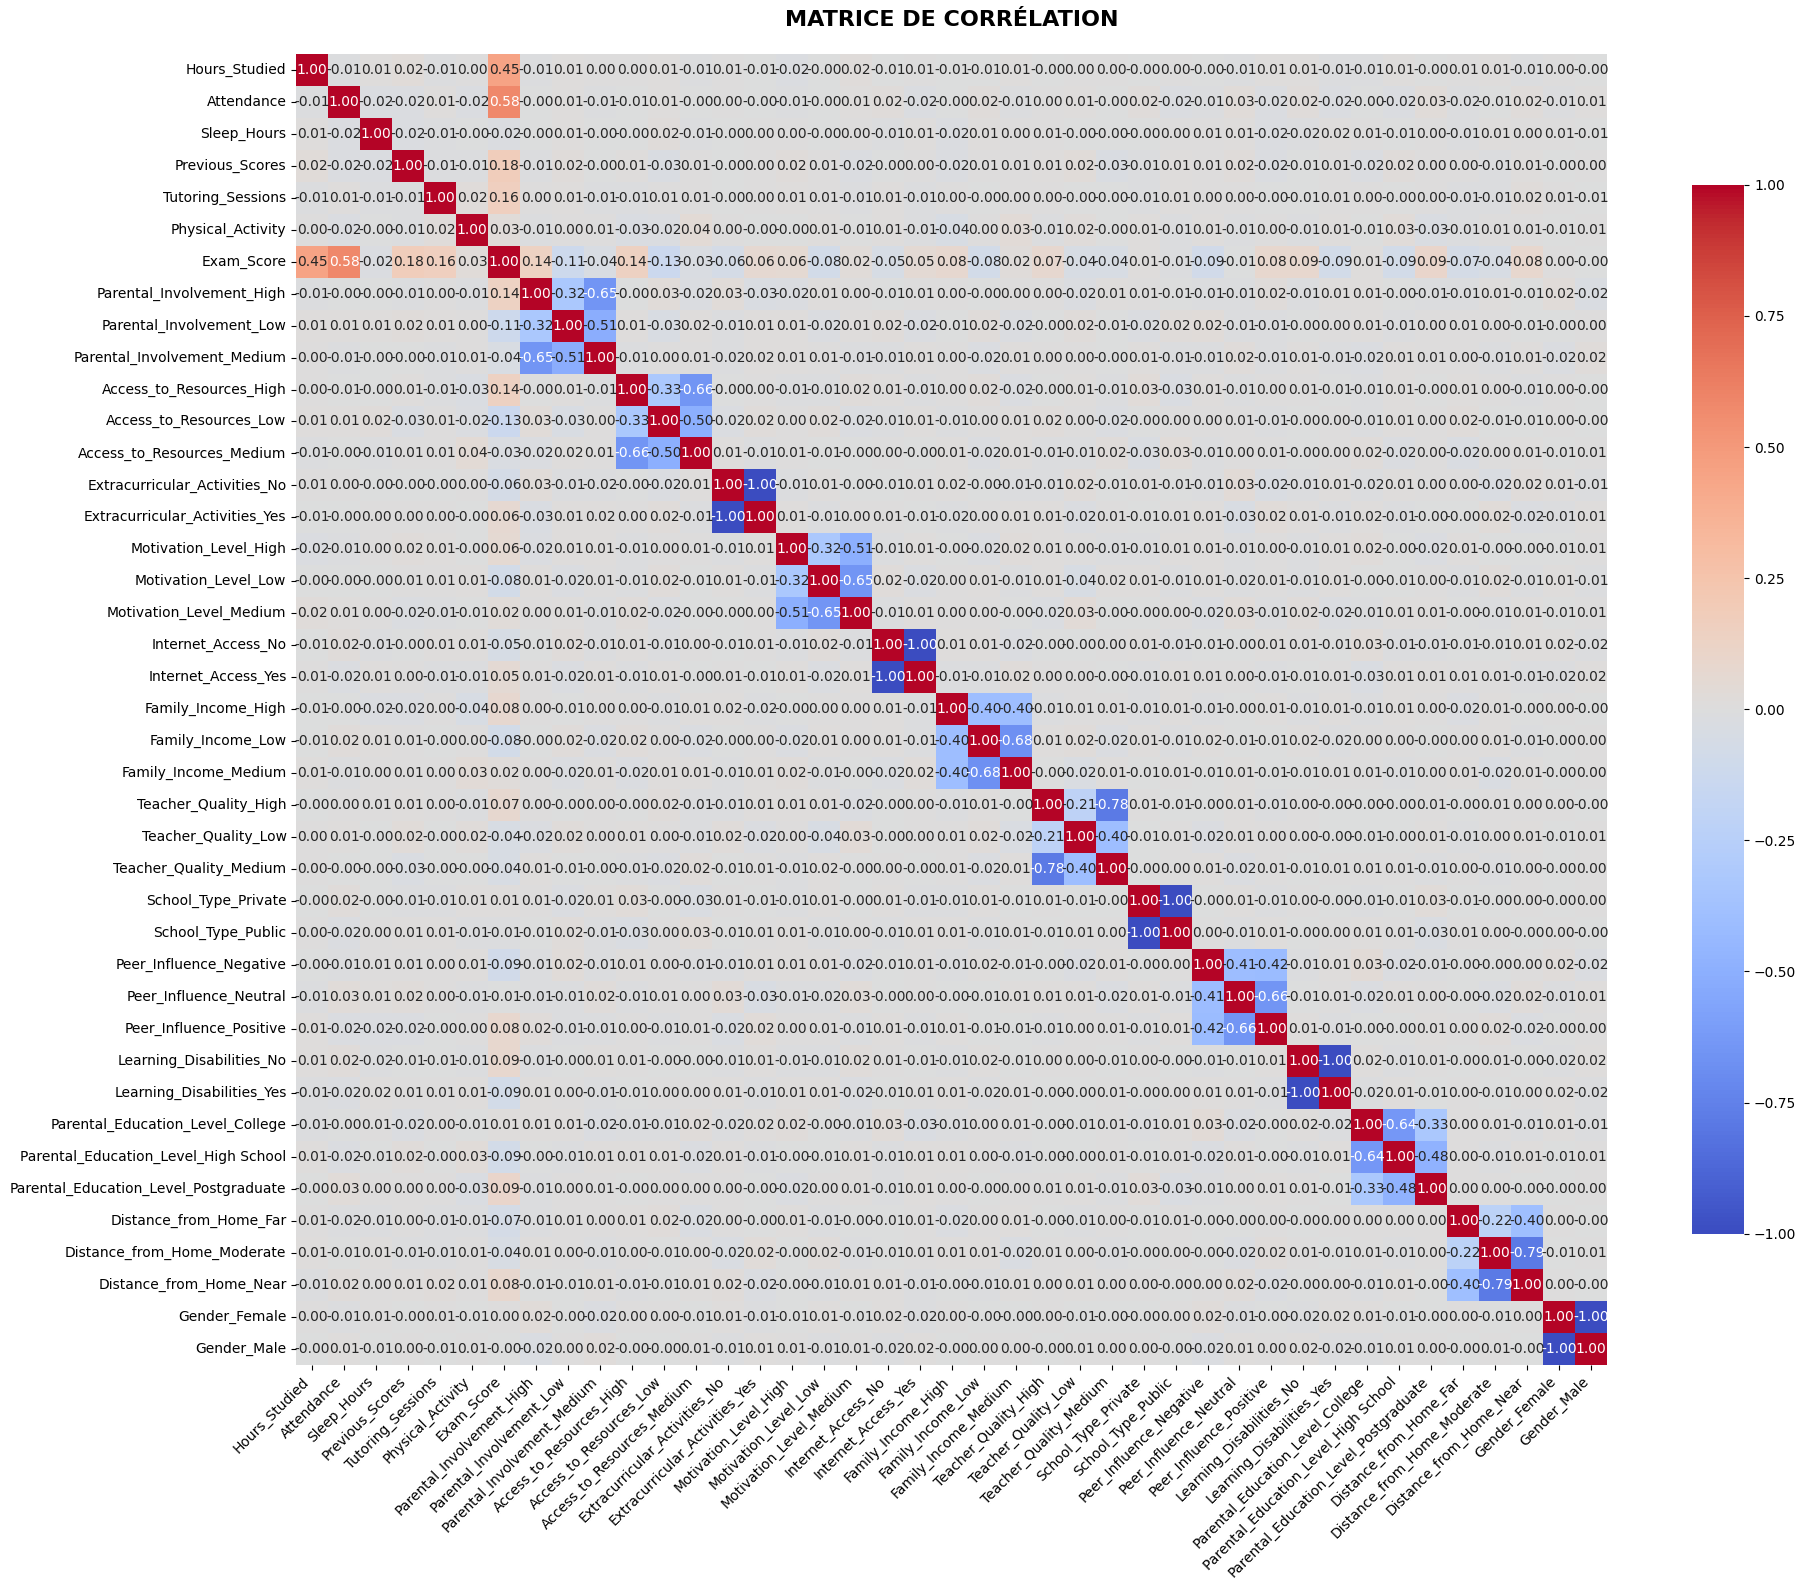

In [17]:
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('MATRICE DE CORRÉLATION', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Pour des soucis de lisibilité, nous allons afficher les corrélations de toutes les variables par rapport à notre variable cible, celle qu'on veut prédire à savoir Exam_Score

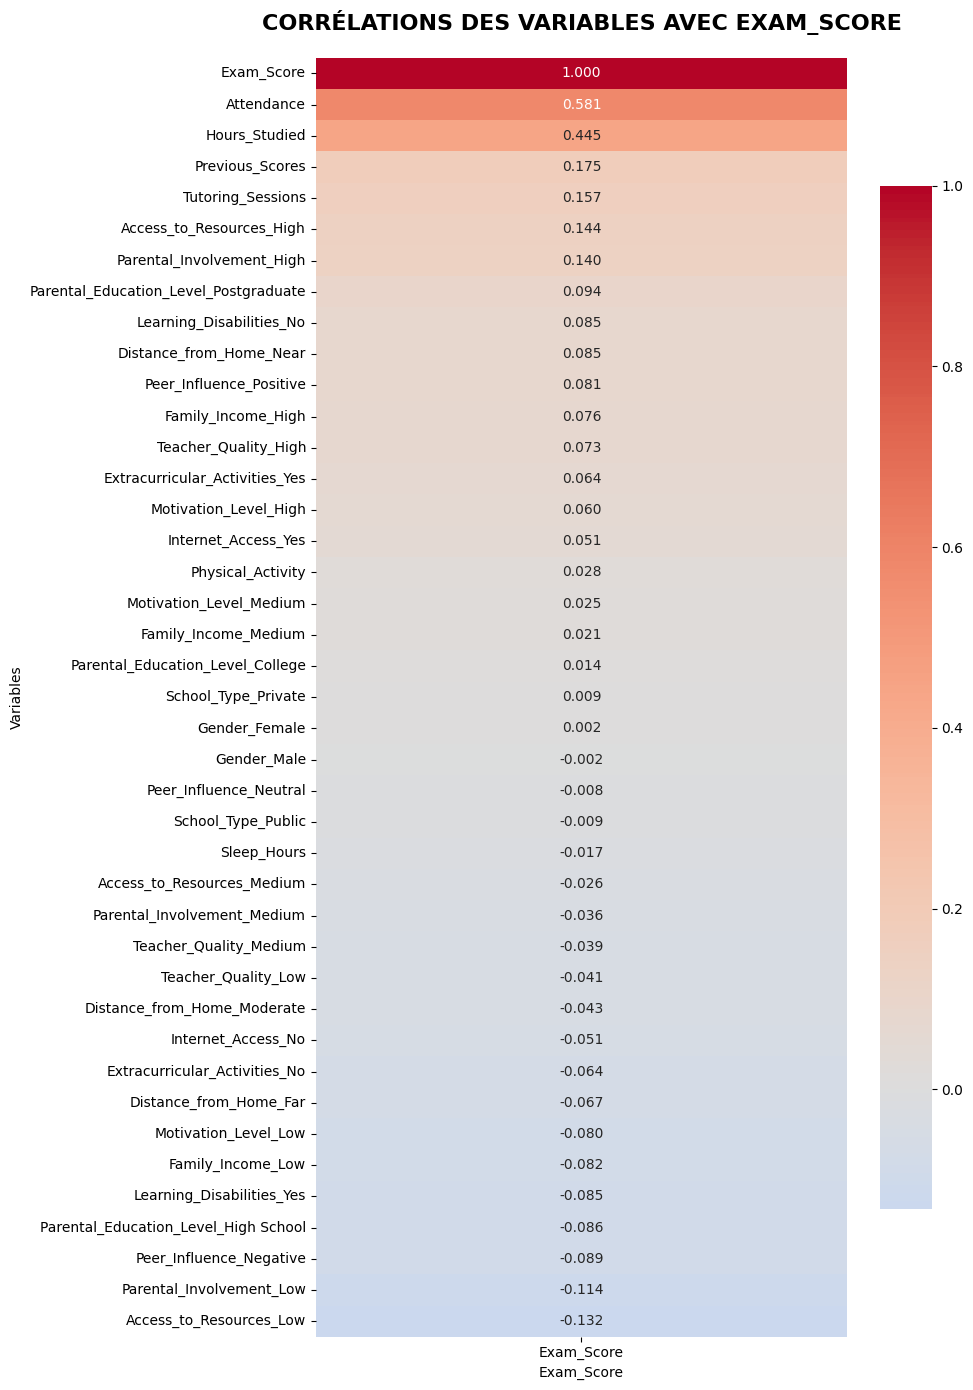

In [18]:
correlations_exam = df_encoded.corr()['Exam_Score'].sort_values(ascending=False)
correlations_exam = df_encoded.corr()['Exam_Score'].sort_values(ascending=False)

plt.figure(figsize=(10, 14))
sns.heatmap(
    correlations_exam.to_frame(),
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    center=0,
    cbar_kws={"shrink": .8}
)

plt.title('CORRÉLATIONS DES VARIABLES AVEC EXAM_SCORE',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Exam_Score')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

## **Traitement des valeurs manquantes**

We know that only three categorical variables have missing values: Teacher_Quality, Parental_Education_Level, and Distance_From_Home.

However, we observe that the number of missing values ​​is very small, representing at most 1.36% of the observations. Given this small proportion, it was decided not to delete the affected rows, but to use an imputation method to preserve the size of the dataset.

Furthermore, the correlation analysis between these three variables and the target variable (Exam_Score) revealed extremely low coefficients of 0.094 and 0.085. Therefore, we can assume that the small influence of these variables on the prediction allows us to hypothesize that the chosen imputation method will have a negligible impact on the model's performance.

To handle these missing values, we will try two different methods that seemed relevant:
1.   Mode Imputation: The missing values ​​will be replaced by the most frequent category (the Mode) of each column. This approach is chosen for the implementation of the standard model.
2.   Imputation by 'Unknown': Missing values ​​will be replaced by the new category 'Unknown'. This approach will be integrated into model improvement tests to determine whether the absence of information, treated as a variable, can refine the prediction results.

In [21]:
colonnes_a_verifier = [
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

for col in colonnes_a_verifier:
    print(f"\n--- Analyse de la colonne : {col} ---")

    proportions = df[col].value_counts(normalize=True).mul(100).round(2)

    print(f"La valeur la plus fréquente est : {proportions.head(1).index.tolist()[0]}")
    print(f"Elle représente : {proportions.head(1).values[0]} %")



--- Analyse de la colonne : Teacher_Quality ---
La valeur la plus fréquente est : Medium
Elle représente : 60.12 %

--- Analyse de la colonne : Parental_Education_Level ---
La valeur la plus fréquente est : High School
Elle représente : 49.46 %

--- Analyse de la colonne : Distance_from_Home ---
La valeur la plus fréquente est : Near
Elle représente : 59.39 %


In [22]:
colonnes_a_imputer_mode = [
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

for col in colonnes_a_imputer_mode:

    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

print("\nVérification avec df.info() :")
df.info()


Vérification avec df.info() :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence   

/tmp/ipython-input-2230620337.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


## **Récupération du df_filtre**

We will only work with the variables that interest us, that is, those most correlated with our target variable, which is the final grade. To select them, we will create a function that will allow us to retrieve only the variables that have exceeded a certain correlation threshold with our target variable.




In [31]:
def selectionner_variables_par_correlation(df_encoded, variable_cible='Exam_Score',
                                         seuil_correlation=0.1, afficher_resultats=True):
  correlations = df_encoded.corr()[variable_cible]
  correlations = correlations[correlations.index != variable_cible]
  variables_selectionnees = correlations[abs(correlations) >= seuil_correlation]
  variables_selectionnees = variables_selectionnees.reindex(
        variables_selectionnees.abs().sort_values(ascending=False).index
  )
  colonnes_finales = list(variables_selectionnees.index) + [variable_cible]
  df_filtre = df_encoded[colonnes_finales]

  if afficher_resultats:
    print(f"Variable cible : {variable_cible}")
    print(f"Seuil de corrélation : |{seuil_correlation}|")
    print(f"Variables originales : {df_encoded.shape[1] - 1}")
    print(f"Variables sélectionnées : {len(variables_selectionnees)}")
    print(f"Variables éliminées : {(df_encoded.shape[1] - 1) - len(variables_selectionnees)}")

  return df_filtre, variables_selectionnees



In [32]:
seuils_a_tester = [0.05, 0.1, 0.2, 0.3, 0.4]

for seuil in seuils_a_tester:
    print(f"\nSEUIL = {seuil}")
    df_temp, corr_temp = selectionner_variables_par_correlation(
        df_encoded,
        seuil_correlation=seuil
    )


SEUIL = 0.05
Variable cible : Exam_Score
Seuil de corrélation : |0.05|
Variables originales : 40
Variables sélectionnées : 25
Variables éliminées : 15

SEUIL = 0.1
Variable cible : Exam_Score
Seuil de corrélation : |0.1|
Variables originales : 40
Variables sélectionnées : 8
Variables éliminées : 32

SEUIL = 0.2
Variable cible : Exam_Score
Seuil de corrélation : |0.2|
Variables originales : 40
Variables sélectionnées : 2
Variables éliminées : 38

SEUIL = 0.3
Variable cible : Exam_Score
Seuil de corrélation : |0.3|
Variables originales : 40
Variables sélectionnées : 2
Variables éliminées : 38

SEUIL = 0.4
Variable cible : Exam_Score
Seuil de corrélation : |0.4|
Variables originales : 40
Variables sélectionnées : 2
Variables éliminées : 38


In [33]:
df_filtre, corr_temp = selectionner_variables_par_correlation(df_encoded, seuil_correlation=0.1)
df_filtre.head()

Variable cible : Exam_Score
Seuil de corrélation : |0.1|
Variables originales : 40
Variables sélectionnées : 8
Variables éliminées : 32


,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Access_to_Resources_High,Parental_Involvement_High,Access_to_Resources_Low,Parental_Involvement_Low,Exam_Score
0,84,23,73,0,True,False,False,True,67
1,64,19,59,2,False,False,False,True,61
2,98,24,91,2,False,False,False,False,74
3,89,29,98,1,False,False,False,True,71
4,92,19,65,3,False,False,False,False,70


Pour la suite, nous allons faire le choix de prendre un seuil de 0.1 car on conserve tout de même 8 variables sur 40 ce qui élimine les 12 variables peu corrélées. On pense que cela représente un bon équilibre entre la réduction et la complexité du modèle et la conservation des facteurs impoprtants qui influent sur les performances à l'examen.

# **Pre-processing :**

In [36]:
df_filtre.info()
df_filtre.isnull().sum()

# On retrouve aucune valeur manquante, on peut passer directement à la séparation X/y(target)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Attendance                 6607 non-null   int64
 1   Hours_Studied              6607 non-null   int64
 2   Previous_Scores            6607 non-null   int64
 3   Tutoring_Sessions          6607 non-null   int64
 4   Access_to_Resources_High   6607 non-null   bool 
 5   Parental_Involvement_High  6607 non-null   bool 
 6   Access_to_Resources_Low    6607 non-null   bool 
 7   Parental_Involvement_Low   6607 non-null   bool 
 8   Exam_Score                 6607 non-null   int64
dtypes: bool(4), int64(5)
memory usage: 284.0 KB


,0
Attendance,0
Hours_Studied,0
Previous_Scores,0
Tutoring_Sessions,0
Access_to_Resources_High,0
Parental_Involvement_High,0
Access_to_Resources_Low,0
Parental_Involvement_Low,0
Exam_Score,0


In [37]:
# On sépare la variable target de X, ici "Exam_Score".
X = df_filtre.drop(columns=['Exam_Score'])
y = df_filtre['Exam_Score']

print(" Données séparées :")
print(f"Taille variable X = {X.shape}, Taille target = {y.shape}")

 Données séparées :
Taille variable X = (6607, 8), Taille target = (6607,)


In [38]:
# On normalise les valeurs
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Access_to_Resources_High,Parental_Involvement_High,Access_to_Resources_Low,Parental_Involvement_Low
0,0.348375,0.504942,-0.143800,-1.213934,1.531443,-0.637216,-0.498013,1.985362
1,-1.383736,-0.162822,-1.116110,0.411451,-0.652979,-0.637216,-0.498013,1.985362
2,1.560853,0.671882,1.106313,0.411451,-0.652979,-0.637216,-0.498013,-0.503687
3,0.781403,1.506587,1.592469,-0.401242,-0.652979,-0.637216,-0.498013,1.985362
4,1.041220,-0.162822,-0.699406,1.224144,-0.652979,-0.637216,-0.498013,-0.503687


### Formalisation du problème

Le problème peut être formalisé comme une tâche de prédiction supervisée, dont
l’objectif est d’estimer la performance d’un étudiant à l’examen à partir de variables explicatives décrivant son profil, ses habitudes d’étude et son environnement.

Nous commençons par un modèle d’arbre de décision, qui offre une première estimation du lien entre les différents facteurs et la note d’examen, tout en restant facilement interprétable.

In [39]:
# Découpe Train/test avec 30% de données de test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.3, random_state=42)

print(list(X.columns))

['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_High', 'Parental_Involvement_High', 'Access_to_Resources_Low', 'Parental_Involvement_Low']


In [40]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Création et entraînement du modèle
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Prédictions
y_pred = tree.predict(X_test)

# Évaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Modèle utilisé : DecisionTreeRegressor")
print(f" Mean Squared Error (MSE) : {mse:.2f}")
print(f" Coefficient de détermination (R²) : {r2:.3f}")

 Modèle utilisé : DecisionTreeRegressor
 Mean Squared Error (MSE) : 11.31
 Coefficient de détermination (R²) : 0.177


In [ ]:
# En entraînant le modèle avec 70 % de données d’apprentissage et 30 % de données de test, on obtient un coefficient de détermination R² = 0.177,
# ce qui indique que le modèle explique très peu de la variance des notes d’examen.

# Essayons en agissant sur les pramètres du DecisionTreeRegressor. Ps : On ne peut pas diminuer le pourcentage de données d'apprentissage, 70/30 reste un bon compromis pour un jeu de cette taille.

tree = DecisionTreeRegressor(min_samples_leaf=5, random_state=42)
# On fixe le nombre minimum d’échantillons qu’une feuille doit contenir à 5

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Modèle utilisé : DecisionTreeRegressor")
print(f" Mean Squared Error (MSE) : {mse:.2f}")
print(f" Coefficient de détermination (R²) : {r2:.3f}")

 Modèle utilisé : DecisionTreeRegressor
 Mean Squared Error (MSE) : 6.24
 Coefficient de détermination (R²) : 0.559


In [ ]:
# Cela indique que le modèle explique désormais près de 56 % de la variance des notes d’examen, contre seulement 17 % auparavant.
# La baisse du MSE traduit une réduction significative de l’erreur moyenne, ce qui explique alors une meilleure généralisation sur le jeu de test !

